<a href="https://colab.research.google.com/github/ravikeerthi7606/HousePricePrediction/blob/main/DataUnderstanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shashanknecrothapa/ames-housing-dataset")

print("Path to dataset files:", path)

100%|██████████| 185k/185k [00:00<00:00, 45.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/shashanknecrothapa/ames-housing-dataset/versions/1


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
#first 5 rows
#DON'T FORGET TO CHANGE THE PATH
df = pd.read_csv('/root/.cache/kagglehub/datasets/shashanknecrothapa/ames-housing-dataset/versions/1/AmesHousing.csv')
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [14]:
#rows and columns
print(f'Shape:{df.shape}')
#Missing values
print(f'Missing value:\n{df.isna().sum().sort_values(ascending=False).head(10)}')

Shape:(2930, 82)
Missing value:
Pool QC          2917
Misc Feature     2824
Alley            2732
Fence            2358
Mas Vnr Type     1775
Fireplace Qu     1422
Lot Frontage      490
Garage Qual       159
Garage Yr Blt     159
Garage Cond       159
dtype: int64


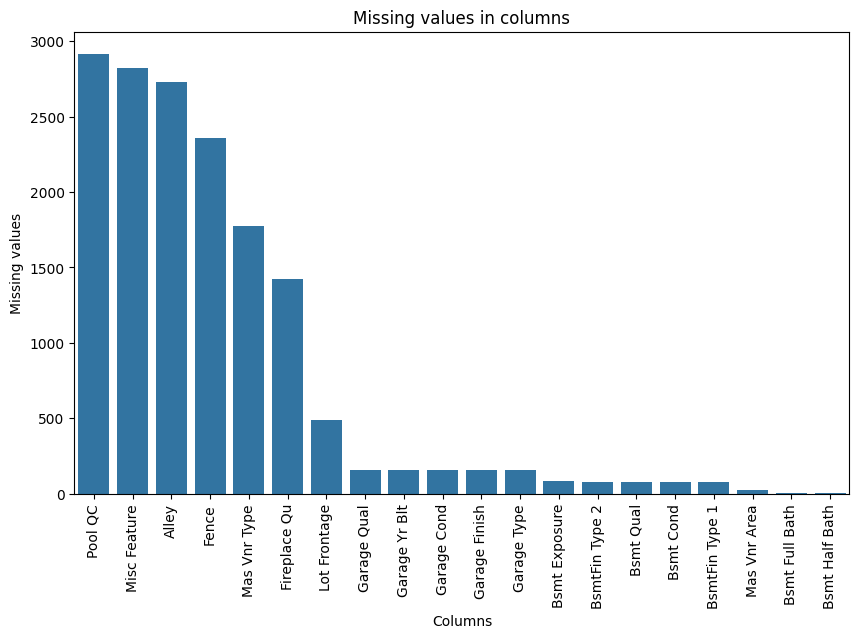

In [27]:
#visualize the missing values in column
Missing_values = df.isna().sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(Missing_values)
plt.title('Missing values in columns')
plt.xlabel('Columns')
plt.ylabel('Missing values')
plt.xticks(rotation=90)
plt.show()

In [13]:
#data types
df.dtypes.value_counts()

,count
object,43
int64,28
float64,11


In [18]:
df['Yr Sold'].value_counts()

,count
Yr Sold,
2007,694
2009,648
2006,625
2008,622
2010,341


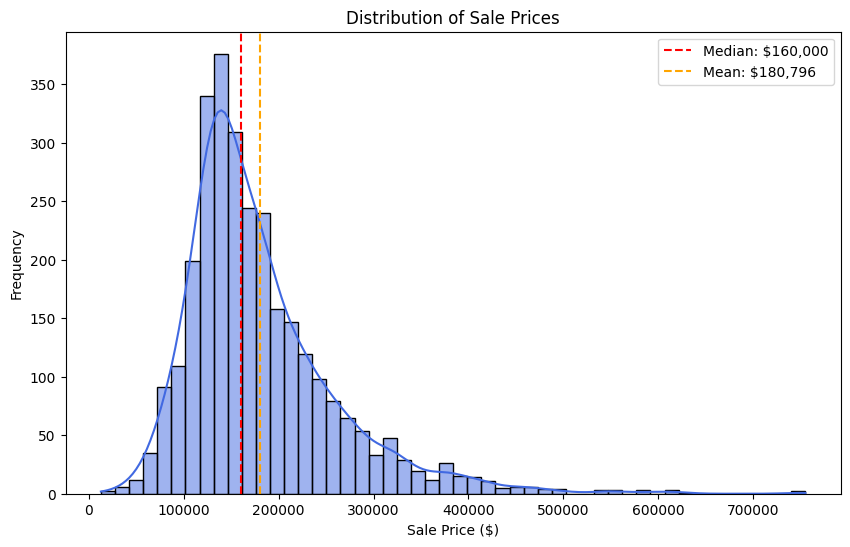

Skewness: 1.74
Kurtosis: 5.12


In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice'], kde=True, bins=50, color='royalblue')
plt.title('Distribution of Sale Prices')
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')
plt.axvline(df['SalePrice'].median(), color='red', linestyle='--', label=f'Median: ${df["SalePrice"].median():,.0f}')
plt.axvline(df['SalePrice'].mean(), color='orange', linestyle='--', label=f'Mean: ${df["SalePrice"].mean():,.0f}')
plt.legend()
plt.show()

print(f"Skewness: {df['SalePrice'].skew():.2f}")
print(f"Kurtosis: {df['SalePrice'].kurt():.2f}")

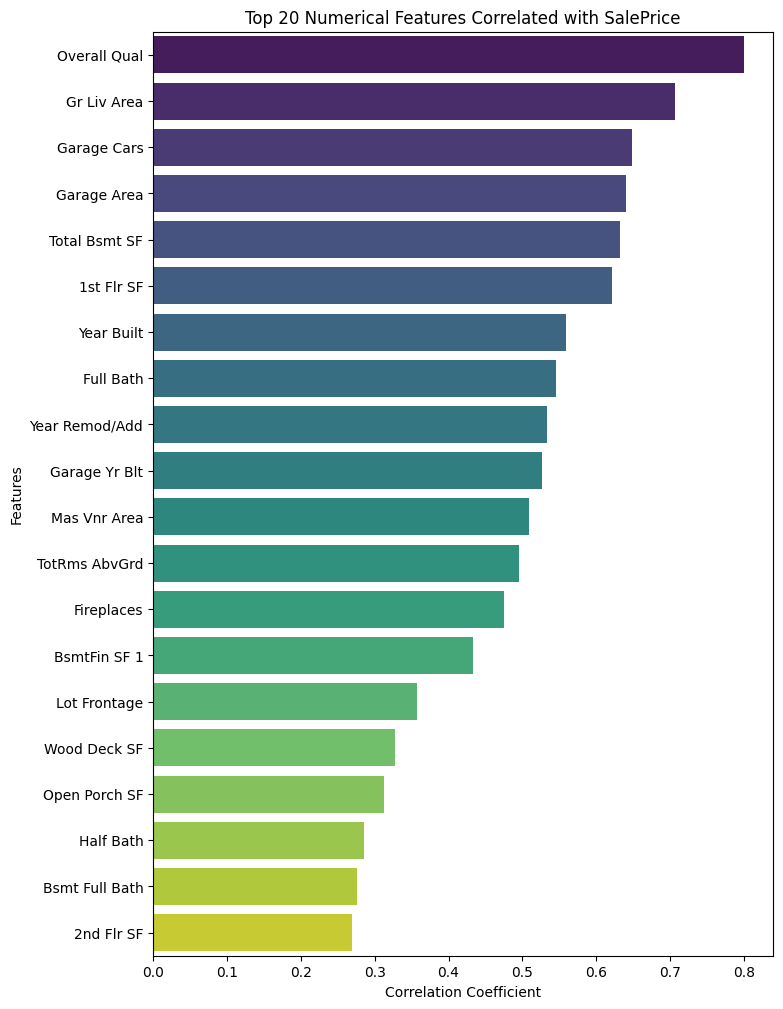

In [25]:
# Select only numeric columns to calculate correlation
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['SalePrice'].sort_values(ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(x=correlations.values[1:21], y=correlations.index[1:21], palette='viridis', hue=correlations.index[1:21], legend=False)
plt.title('Top 20 Numerical Features Correlated with SalePrice')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.show()